# CNN-DDQN Extension on highway-v0
Mohammed SBAIHI

This notebook trains a Double DQN agent from raw pixel observations (stacked grayscale frames).
The setup follows the shared benchmark config, with only the observation representation changed to images.

In [ ]:
# the following code is a simple fix because I am using a headless VM with no sound card
# and it keeps throwing errors related to ALSA and SDL audio drivers.

import os
from pathlib import Path

Path("/tmp/xdg-runtime").mkdir(parents=True, exist_ok=True)
os.chmod("/tmp/xdg-runtime", 0o700)
os.environ["XDG_RUNTIME_DIR"] = "/tmp/xdg-runtime"

Path("/tmp/asound.conf").write_text(
"pcm.!default { type null }\nctl.!default { type null }\n",
encoding="utf-8",
)
os.environ["ALSA_CONFIG_PATH"] = "/tmp/asound.conf"
os.environ["SDL_AUDIODRIVER"] = "dummy"

In [3]:
import sys, torch
print(sys.executable)
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

/usr/local/bin/python
2.8.0+cu128 12.8 True
NVIDIA RTX A6000


In [4]:
import os, torch
print("cuda:", torch.cuda.is_available())
print("SDL_AUDIODRIVER:", os.environ.get("SDL_AUDIODRIVER"))
print("ALSA_CONFIG_PATH:", os.environ.get("ALSA_CONFIG_PATH"))

cuda: True
SDL_AUDIODRIVER: dummy
ALSA_CONFIG_PATH: /tmp/asound.conf


In [5]:
import csv
import os
import json
import math
import time
import random
import statistics as stats
from collections import namedtuple, deque
from dataclasses import dataclass, asdict
from itertools import count

import gymnasium as gym
import highway_env
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from extension_cnn_config import CNN_DDQN_CONFIG, CNN_DDQN_ENV_ID

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available on this system. \n" \
    "I ran my experiments on a machine with a GPU, \n" \
    "so I recommend running this nb on a GPU where CUDA is available.")

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True
if hasattr(torch.backends.cuda, "matmul"):
    torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda")
print("CUDA available:", device)

CUDA available: cuda


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [6]:
RUN_ID = time.strftime("%Y%m%d-%H%M%S")
RUN_DIR = os.path.join("real_checkpoints_ext2", "cnn_ddqn", f"run_{RUN_ID}")
os.makedirs(RUN_DIR, exist_ok=True)
print("run dir:", RUN_DIR)

def make_env(seed: int, render: bool = False) -> gym.Env:
    config = dict(CNN_DDQN_CONFIG)
    render_mode = None
    if render:
        config["offscreen_rendering"] = True
        render_mode = "rgb_array"

    env = gym.make(CNN_DDQN_ENV_ID, config=config, render_mode=render_mode)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

run dir: real_checkpoints_ext2/cnn_ddqn/run_20260413-130110


In [9]:
@dataclass
class CnnDDQNConfig:
    replay_capacity: int = 100_000
    batch_size: int = 64
    learning_starts: int = 1_000

    gamma: float = 0.99
    target_update_every: int = 1_000

    eps_start: float = 1.0
    eps_end: float = 0.05
    eps_decay: int = 7_000

    lr: float = 1e-4

    num_episodes: int = 1_500
    eval_episodes: int = 50
    checkpoint_every: int = 50
    best_avg_window: int = 20

In [10]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def obs_to_tensor(obs, device_override: torch.device | None = None) -> torch.Tensor:
    arr = np.asarray(obs, dtype=np.float32) / 255.0

    if arr.ndim == 2:
        arr = arr[None, :, :]
    elif arr.ndim == 3 and arr.shape[0] not in (1, 4):
        arr = np.transpose(arr, (2, 0, 1))

    tensor = torch.from_numpy(arr).unsqueeze(0)
    if device_override is not None:
        tensor = tensor.to(device_override, non_blocking=True)
    return tensor

observation shape: (4, 84, 84) dtype: uint8


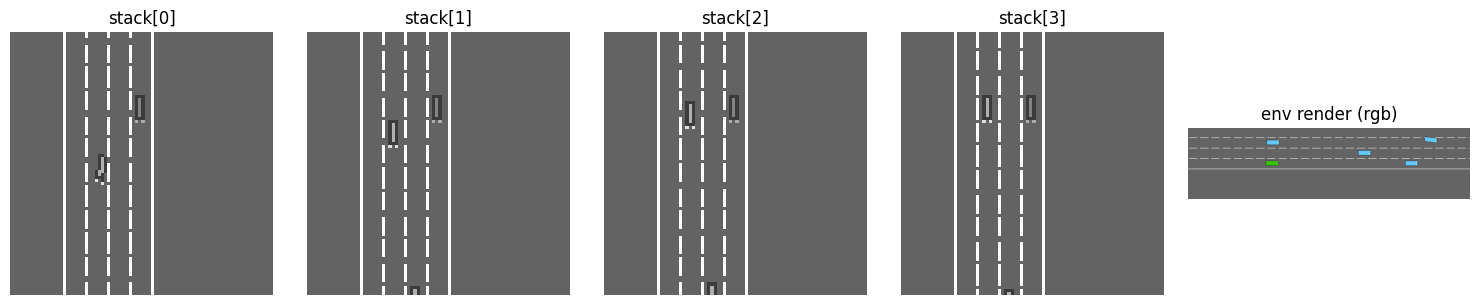

In [ ]:
# -- visualize one stacked grayscale observation and the RGB render
viz_seed = 0
viz_env = make_env(viz_seed, render=True)
obs, _ = viz_env.reset(seed=viz_seed)

obs, _ = viz_env.reset(seed=viz_seed)

steps_since_reset = 0
while steps_since_reset < 4:
    action = viz_env.action_space.sample()
    obs, _, terminated, truncated, _ = viz_env.step(action)
    if terminated or truncated:
        obs, _ = viz_env.reset(seed=viz_seed)
        steps_since_reset = 0
    else:
        steps_since_reset += 1
    

stacked = np.asarray(obs)
print("observation shape:", stacked.shape, "dtype:", stacked.dtype)


rgb_frame = viz_env.render()
vmax = 1.0 if float(stacked.max()) <= 1.0 else 255.0

fig, axes = plt.subplots(1, stacked.shape[0] + 1, figsize=(3 * (stacked.shape[0] + 1), 3))
for i in range(stacked.shape[0]):
    axes[i].imshow(stacked[i], cmap="gray", vmin=0.0, vmax=vmax)
    axes[i].set_title(f"stack[{i}]")
    axes[i].axis("off")

axes[-1].imshow(rgb_frame)
axes[-1].set_title("env render (rgb)")
axes[-1].axis("off")

plt.tight_layout()
plt.show()
viz_env.close()

In [ ]:
Transition = namedtuple("Transition", ("state", "action", "next_state", "reward"))

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size: int):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class CNNQNet(nn.Module):
    def __init__(self, in_channels: int, n_actions: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 84, 84)
            feat_dim = self.features(dummy).view(1, -1).size(1)

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Linear(256, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.head(x)

In [ ]:
class DDQNCNNAgent:
    def __init__(self, env: gym.Env, cfg: CnnDDQNConfig, seed: int):
        self.env = env
        self.cfg = cfg
        self.seed = seed
        self.name = "cnn_ddqn"

        set_seed(seed)
        obs, _ = env.reset(seed=seed)
        obs_t = obs_to_tensor(obs)

        self.in_channels = int(obs_t.shape[1])
        self.n_actions = env.action_space.n

        self.policy_net = CNNQNet(self.in_channels, self.n_actions).to(device)
        self.target_net = CNNQNet(self.in_channels, self.n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.lr)
        self.memory = ReplayBuffer(cfg.replay_capacity)
        self.steps_done = 0
        self.use_amp = device.type == "cuda"
        self.grad_scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp)

    def epsilon(self) -> float:
        if self.steps_done < self.cfg.learning_starts:
            return self.cfg.eps_start
        t = self.steps_done - self.cfg.learning_starts
        return self.cfg.eps_end + (self.cfg.eps_start - self.cfg.eps_end) * math.exp(
            -t / self.cfg.eps_decay
        )

    def select_action(self, state: torch.Tensor) -> torch.Tensor:
        eps = self.epsilon()
        self.steps_done += 1

        if random.random() > eps:
            state_device = state.to(device, non_blocking=True)
            with torch.no_grad(), torch.amp.autocast("cuda", enabled=self.use_amp):
                action = self.policy_net(state_device).argmax(dim=1, keepdim=True)
            return action.to("cpu")

        return torch.tensor([[self.env.action_space.sample()]], dtype=torch.long)

    def optimize(self) -> None:
        if len(self.memory) < max(self.cfg.batch_size, self.cfg.learning_starts):
            return

        transitions = self.memory.sample(self.cfg.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(
            [s is not None for s in batch.next_state],
            dtype=torch.bool,
            device=device,
        )
        non_final_next_states = [s for s in batch.next_state if s is not None]
        if non_final_next_states:
            non_final_next_states = torch.cat(non_final_next_states).to(device, non_blocking=True)
        else:
            non_final_next_states = torch.empty(
                (0, self.in_channels, 84, 84), dtype=torch.float32, device=device
            )

        state_batch = torch.cat(batch.state).to(device, non_blocking=True)
        action_batch = torch.cat(batch.action).to(device=device, dtype=torch.long, non_blocking=True)
        reward_batch = torch.cat(batch.reward).to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=self.use_amp):
            q_values = self.policy_net(state_batch).gather(1, action_batch)

            next_q = torch.zeros(self.cfg.batch_size, device=device, dtype=torch.float32)
            with torch.no_grad():
                if non_final_next_states.numel() > 0:
                    best_actions = self.policy_net(non_final_next_states).argmax(dim=1, keepdim=True)
                    selected_next_q = self.target_net(non_final_next_states).gather(
                        1, best_actions
                    ).squeeze(1).to(dtype=next_q.dtype)
                    next_q[non_final_mask] = selected_next_q

            target = (reward_batch + self.cfg.gamma * next_q).unsqueeze(1).to(dtype=q_values.dtype)
            loss = F.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad(set_to_none=True)
        self.grad_scaler.scale(loss).backward()
        self.grad_scaler.unscale_(self.optimizer)
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)
        self.grad_scaler.step(self.optimizer)
        self.grad_scaler.update()

    def save_checkpoint(
        self,
        path: str,
        episode: int,
        episode_rewards: list[float],
        best: bool = False,
    ) -> None:
        payload = {
            "policy_state_dict": self.policy_net.state_dict(),
            "target_state_dict": self.target_net.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "scaler_state_dict": self.grad_scaler.state_dict(),
            "steps_done": self.steps_done,
            "episode": episode,
            "seed": self.seed,
            "config": asdict(self.cfg),
            "in_channels": self.in_channels,
            "n_actions": self.n_actions,
            "episode_rewards": episode_rewards,
            "best": best,
        }
        torch.save(payload, path)

    def train(
        self,
        run_seed_dir: str,
        plot_live: bool = False,
    ) -> tuple[list[float], list[int], str]:
        rewards = []
        lengths = []
        crashes = []
        best_avg = float("-inf")
        best_path = os.path.join(run_seed_dir, "best.pt")

        csv_path = os.path.join(run_seed_dir, "training_stats.csv")
        csv_is_new = not os.path.exists(csv_path)
        csv_file = open(csv_path, "a", newline="", encoding="utf-8")
        csv_writer = csv.writer(csv_file)
        if csv_is_new:
            csv_writer.writerow(["episode", "reward", "crashed", "length"])
            csv_file.flush()

        try:
            for i_episode in range(self.cfg.num_episodes):
                obs, _ = self.env.reset(seed=self.seed + i_episode)
                state = obs_to_tensor(obs)
                total_reward = 0.0
                episode_crashed = 0

                for t in count():
                    action = self.select_action(state)
                    next_obs, reward, terminated, truncated, info = self.env.step(int(action.item()))
                    done = terminated or truncated
                    if info.get("crashed", False):
                        episode_crashed = 1

                    next_state = None if done else obs_to_tensor(next_obs)
                    reward_t = torch.tensor([reward], dtype=torch.float32)
                    self.memory.push(state, action, next_state, reward_t)

                    state = next_state if next_state is not None else state
                    total_reward += reward

                    self.optimize()

                    if self.steps_done % self.cfg.target_update_every == 0:
                        self.target_net.load_state_dict(self.policy_net.state_dict())

                    if done:
                        rewards.append(total_reward)
                        lengths.append(t + 1)
                        crashes.append(episode_crashed)
                        csv_writer.writerow([i_episode + 1, total_reward, episode_crashed, t + 1])
                        csv_file.flush()
                        break

                if (i_episode + 1) % self.cfg.checkpoint_every == 0:
                    ckpt_path = os.path.join(run_seed_dir, f"ep_{i_episode + 1:05d}.pt")
                    self.save_checkpoint(ckpt_path, i_episode + 1, rewards, best=False)

                if len(rewards) >= self.cfg.best_avg_window:
                    window_avg = stats.mean(rewards[-self.cfg.best_avg_window :])
                    if window_avg > best_avg:
                        best_avg = window_avg
                        self.save_checkpoint(best_path, i_episode + 1, rewards, best=True)

                if plot_live and (i_episode + 1) % 20 == 0:
                    avg_window = min(20, len(rewards))
                    avg_reward = stats.mean(rewards[-avg_window:])
                    avg_crash = stats.mean(crashes[-avg_window:]) if crashes else 0.0
                    print(
                        f"episode {i_episode + 1}/{self.cfg.num_episodes} "
                        f"| reward={total_reward:.3f} "
                        f"| avg{avg_window}={avg_reward:.3f} "
                        f"| crash{avg_window}={avg_crash * 100:.1f}%"
                    )
        finally:
            csv_file.close()

        final_path = os.path.join(run_seed_dir, "final.pt")
        self.save_checkpoint(final_path, self.cfg.num_episodes, rewards, best=False)
        if not os.path.exists(best_path):
            best_path = final_path

        return rewards, lengths, best_path

In [15]:
def plot_training_curve(rewards: list[float], title: str, save_path: str) -> None:
    plt.figure(figsize=(10, 4))
    xs = np.arange(len(rewards))
    ys = np.array(rewards, dtype=np.float32)
    plt.plot(xs, ys, alpha=0.35, label="episode reward")

    if len(rewards) >= 100:
        kernel = np.ones(100, dtype=np.float32) / 100.0
        ma = np.convolve(ys, kernel, mode="valid")
        ma_xs = np.arange(99, len(rewards))
        plt.plot(ma_xs, ma, linewidth=2, label="100-episode moving average")

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.show()

In [16]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    return obj

def evaluate_policy(
    env: gym.Env,
    n_episodes: int,
    seed_offset: int,
    in_channels: int,
    n_actions: int,
    cfg_dict: dict,
    seed: int,
    checkpoint_path: str,
    run_seed_dir: str,
    run_label: str,
    all_rewards: list[float],
) -> dict:
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    eval_net = CNNQNet(in_channels, n_actions).to(device)
    eval_net.load_state_dict(ckpt["policy_state_dict"])
    eval_net.eval()

    rewards = []
    lengths = []
    crashes = 0

    with torch.no_grad():
        for i in range(n_episodes):
            obs, _ = env.reset(seed=seed_offset + i)
            state = obs_to_tensor(obs, device_override=device)
            total_r = 0.0

            for t in count():
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    action = eval_net(state).argmax(dim=1, keepdim=True)
                obs, reward, terminated, truncated, info = env.step(int(action.item()))
                total_r += reward

                if terminated or truncated:
                    if info.get("crashed", False):
                        crashes += 1
                    rewards.append(total_r)
                    lengths.append(t + 1)
                    break

                state = obs_to_tensor(obs, device_override=device)

    summary = {
        "mean_reward": float(stats.mean(rewards)),
        "std_reward": float(stats.stdev(rewards)) if len(rewards) > 1 else 0.0,
        "mean_length": float(stats.mean(lengths)),
        "std_length": float(stats.stdev(lengths)) if len(lengths) > 1 else 0.0,
        "crash_rate": float(crashes / n_episodes),
    }

    metrics_payload = {
        "label": run_label,
        "seed": seed,
        "config": cfg_dict,
        "in_channels": in_channels,
        "n_actions": n_actions,
        "eval_episodes": n_episodes,
        "checkpoint_path": checkpoint_path,
        "eval": summary,
        "raw_eval_rewards": rewards,
        "train_rewards": all_rewards,
    }

    metrics_path = os.path.join(run_seed_dir, "metrics_seed.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(metrics_payload), f, indent=2)

    return summary

In [17]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cfg = CnnDDQNConfig(gamma=0.99)
SEEDS = [0, 1, 2]

if "to_jsonable" not in globals():
    def to_jsonable(obj):
        if isinstance(obj, dict):
            return {str(k): to_jsonable(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [to_jsonable(v) for v in obj]
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.generic):
            return obj.item()
        return obj

if "RUN_RESULTS_BY_SEED" not in globals():
    RUN_RESULTS_BY_SEED = {}

results = []

def _refresh_results_list() -> None:
    global results
    results = [RUN_RESULTS_BY_SEED[s] for s in sorted(RUN_RESULTS_BY_SEED.keys())]

def run_one_seed(
    run_seed: int,
    *,
    cfg_override: CnnDDQNConfig | None = None,
    plot_live: bool = True,
) -> dict:
    cfg_local = cfg if cfg_override is None else cfg_override

    run_seed_dir = os.path.join(RUN_DIR, f"seed_{run_seed}")
    os.makedirs(run_seed_dir, exist_ok=True)

    print(f"\n{'=' * 70}")
    print(f"Seed {run_seed}")
    print(f"{'=' * 70}")
    print("training...")

    env = make_env(run_seed, render=False)
    eval_env = None
    try:
        agent = DDQNCNNAgent(env, cfg_local, run_seed)
        rewards, lengths, best_ckpt_path = agent.train(run_seed_dir=run_seed_dir, plot_live=plot_live)

        curve_path = os.path.join(run_seed_dir, "training_curve.png")
        plot_training_curve(rewards, f"CNN-DDQN Training | seed={run_seed}", curve_path)

        eval_env = make_env(run_seed + 1000, render=False)
        eval_summary = evaluate_policy(
            env=eval_env,
            n_episodes=cfg_local.eval_episodes,
            seed_offset=run_seed + 2000,
            in_channels=agent.in_channels,
            n_actions=agent.n_actions,
            cfg_dict=asdict(cfg_local),
            seed=run_seed,
            checkpoint_path=best_ckpt_path,
            run_seed_dir=run_seed_dir,
            run_label="cnn_ddqn_pixels",
            all_rewards=rewards,
        )

        result = {
            "seed": run_seed,
            **eval_summary,
            "best_checkpoint": best_ckpt_path,
            "param_count": count_parameters(agent.policy_net),
        }
        RUN_RESULTS_BY_SEED[run_seed] = result
        _refresh_results_list()

        seed_summary_path = os.path.join(run_seed_dir, "seed_result_summary.json")
        with open(seed_summary_path, "w", encoding="utf-8") as f:
            json.dump(to_jsonable(result), f, indent=2)

        print(
            f"seed={run_seed} | mean={eval_summary['mean_reward']:.3f} +- {eval_summary['std_reward']:.3f} "
            f"| crash={eval_summary['crash_rate'] * 100:.1f}%"
        )

        return result
    finally:
        if eval_env is not None:
            eval_env.close()
        env.close()

def aggregate_results(required_seeds: list[int] | None = None) -> dict:
    if required_seeds is None:
        required_seeds = SEEDS

    missing = [s for s in required_seeds if s not in RUN_RESULTS_BY_SEED]
    if missing:
        raise ValueError(
            f"Missing seed results for: {missing}. Run those seed cells first, then aggregate."
        )

    per_seed = [RUN_RESULTS_BY_SEED[s] for s in required_seeds]

    global results
    results = per_seed

    aggregate = {
        "mean_reward": float(stats.mean([r["mean_reward"] for r in per_seed])),
        "std_over_seeds": float(stats.stdev([r["mean_reward"] for r in per_seed])) if len(per_seed) > 1 else 0.0,
        "mean_crash_rate": float(stats.mean([r["crash_rate"] for r in per_seed])),
    }

    all_metrics = {
        "label": "cnn_ddqn_pixels",
        "run_id": RUN_ID,
        "gamma": cfg.gamma,
        "seeds": required_seeds,
        "config": asdict(cfg),
        "per_seed": per_seed,
        "aggregate": aggregate,
    }

    all_metrics_path = os.path.join(RUN_DIR, "cnn_ddqn_metrics.json")
    with open(all_metrics_path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(all_metrics), f, indent=2)

    print("\nSaved metrics:", all_metrics_path)
    print("Aggregate:", aggregate)
    return all_metrics


Seed 0
training...
episode 20/1500 | reward=19.033 | avg20=9.335 | crash20=85.0%
episode 40/1500 | reward=9.780 | avg20=9.938 | crash20=90.0%
episode 60/1500 | reward=10.754 | avg20=11.829 | crash20=90.0%
episode 80/1500 | reward=6.917 | avg20=8.595 | crash20=90.0%
episode 100/1500 | reward=18.778 | avg20=9.404 | crash20=95.0%
episode 120/1500 | reward=11.460 | avg20=9.231 | crash20=95.0%
episode 140/1500 | reward=3.051 | avg20=10.287 | crash20=95.0%
episode 160/1500 | reward=1.960 | avg20=8.325 | crash20=100.0%
episode 180/1500 | reward=5.082 | avg20=8.699 | crash20=95.0%
episode 200/1500 | reward=5.955 | avg20=7.362 | crash20=100.0%
episode 220/1500 | reward=8.453 | avg20=8.367 | crash20=95.0%
episode 240/1500 | reward=5.957 | avg20=7.904 | crash20=95.0%
episode 260/1500 | reward=17.863 | avg20=9.136 | crash20=100.0%
episode 280/1500 | reward=6.653 | avg20=7.055 | crash20=100.0%
episode 300/1500 | reward=12.003 | avg20=7.710 | crash20=100.0%
episode 320/1500 | reward=11.128 | avg20=

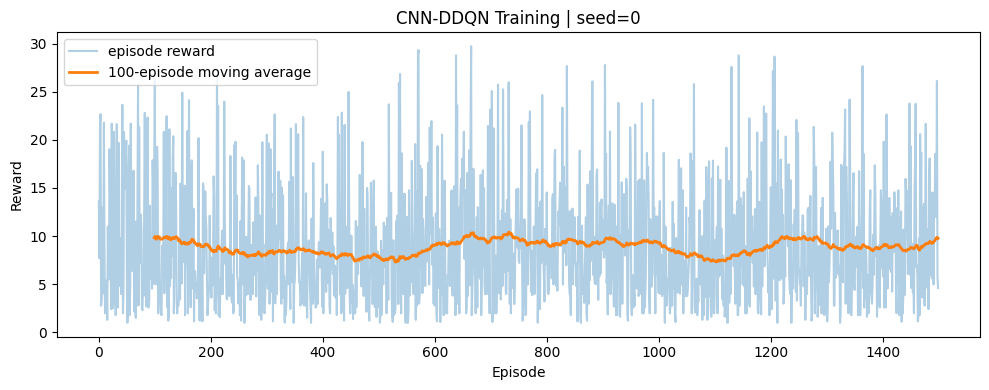

seed=0 | mean=9.955 +- 6.351 | crash=100.0%


In [18]:
seed0_result = run_one_seed(0, plot_live=True)

In [ ]:
seed1_result = run_one_seed(1, plot_live=True)

In [ ]:
seed2_result = run_one_seed(2, plot_live=True)

In [ ]:
all_metrics = aggregate_results(SEEDS)

In [19]:
def load_policy_from_checkpoint(checkpoint_path: str):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    seed = int(ckpt["seed"] )
    env = make_env(seed, render=False)
    obs, _ = env.reset(seed=seed)
    obs_t = obs_to_tensor(obs)
    in_channels = int(obs_t.shape[1])
    n_actions = env.action_space.n

    policy = CNNQNet(in_channels, n_actions).to(device)
    policy.load_state_dict(ckpt["policy_state_dict"] )
    policy.eval()
    env.close()

    return policy, in_channels, n_actions, seed

def record_video_from_checkpoint(
    checkpoint_path: str,
    video_dir: str,
    episodes: int = 3,
    seed_offset: int = 0,
) -> None:
    policy, _, _, base_seed = load_policy_from_checkpoint(checkpoint_path)

    os.makedirs(video_dir, exist_ok=True)
    env = make_env(base_seed + seed_offset, render=True)
    env = gym.wrappers.RecordVideo(
        env,
        video_folder=video_dir,
        episode_trigger=lambda ep: ep < episodes,
        name_prefix="cnn_ddqn",
    )

    with torch.no_grad():
        for ep in range(episodes):
            obs, _ = env.reset(seed=base_seed + seed_offset + ep)
            state = obs_to_tensor(obs, device_override=device)
            done = False

            while not done:
                action = policy(state).argmax(dim=1, keepdim=True)
                obs, _, terminated, truncated, _ = env.step(int(action.item()))
                done = terminated or truncated
                if not done:
                    state = obs_to_tensor(obs, device_override=device)

    env.close()
    print("videos saved to:", os.path.abspath(video_dir))

best_seed = max(results, key=lambda r: r["mean_reward"])["seed"]
best_seed_ckpt = [r["best_checkpoint"] for r in results if r["seed"] == best_seed][0]
video_output_dir = os.path.join(RUN_DIR, f"videos_seed_{best_seed}")

record_video_from_checkpoint(
    checkpoint_path=best_seed_ckpt,
    video_dir=video_output_dir,
    episodes=3,
    seed_offset=5000,
)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /workspace/real_checkpoints_ext2/cnn_ddqn/run_20260413-130110/videos_seed_0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


videos saved to: /workspace/real_checkpoints_ext2/cnn_ddqn/run_20260413-130110/videos_seed_0


In [ ]:
def mlp_param_count(n_obs: int = 50, hidden_size: int = 256, n_actions: int = 5) -> int:
    return (n_obs * hidden_size + hidden_size) + (hidden_size * hidden_size + hidden_size) + (hidden_size * n_actions + n_actions)

cnn_params = results[0]["param_count"] if results else None
mlp_params = mlp_param_count()

print("CNN params:", cnn_params)
print("MLP params:", mlp_params)
if cnn_params is not None and mlp_params > 0:
    print("CNN/MLP ratio:", round(cnn_params / mlp_params, 2))